In [9]:
import numpy as np
from astropy.io import fits
import galsim
import galsim.des
import superbit_lensing.utils as utils
import matplotlib.pyplot as plt

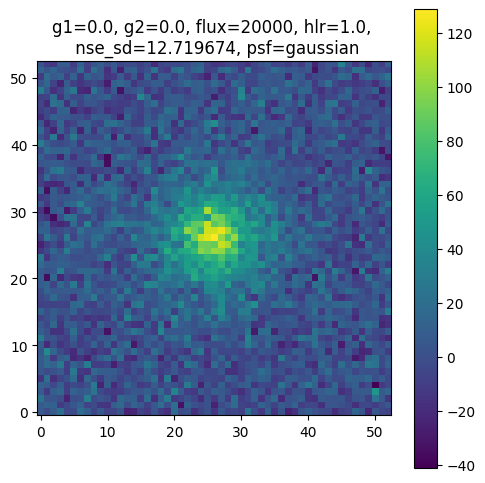

In [43]:
GALSIM_PSF = galsim.des.DES_PSFEx("/home/adfield/SHEARNET_DATA/psfex-output/Abell3411_1_300_1684688714_clean_starcat.psf", wcs=utils.get_galsim_tanwcs())

seed = 42
rng = np.random.RandomState(seed)

gsp=galsim.GSParams(maximum_fft_size=32768)
psf_type = "gaussian"
hlr = 1.0 #0.5
psf_fwhm = 0.5
flux = 20000 #12258.97
g1 = 0.0
g2 = 0.0
npix = 53
scale = 0.141
noise = 12.719674
if psf_type=="superbit":
    image_xsize=9600 
    image_ysize=6400
    margin = 500
    x_im = rng.randint(margin, image_xsize - margin)
    y_im = rng.randint(margin, image_ysize - margin)
    image_position = galsim.PositionD(x_im, y_im)
    psf = GALSIM_PSF.getPSF(image_position)
elif psf_type=="gaussian":
    psf = galsim.Gaussian(fwhm=psf_fwhm)
obj0 = galsim.Exponential(half_light_radius=hlr, flux=flux).shear(g1=g1, g2=g2)
obj0_psf = galsim.Convolve(psf, obj0, gsparams=gsp)
im_0 = obj0_psf.drawImage(nx=npix, ny=npix, scale=scale).array
im_noise = rng.normal(scale=noise, size=im_0.shape)
im_0 += im_noise

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(im_0, origin='lower', cmap='viridis')
plt.colorbar(im, ax=ax)
ax.set_title(f'g1={g1}, g2={g2}, flux={flux}, hlr={hlr}, \n nse_sd={noise}, psf={psf_type}')
plt.tight_layout()
plt.show()